# 04 · Quick start: a hydrological model (GR4J)

Same GPU interface as `00_quickstart`, but the deterministic core is now **GR4J** — a
4-parameter lumped conceptual rainfall-runoff model — instead of the default MLP.

- `predict(X)` → point estimate (median band)
- `predict_quantiles(X)` → probabilistic bands

The only thing that changes for you is the **forcing**. GR4J reads two named columns of
`X`, precipitation `P` and potential evapotranspiration `PET`, both in **mm/day**, and
returns a non-negative runoff depth in mm/day. Its four calibrated parameters
(`X1..X4`) are *not* constructor arguments — the optimiser owns them, so `GR4JModel()`
is instantiated bare and GPU searches them inside their natural physical ranges.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.models import GR4JModel
from foresight_gpu.utils import plot_timeseries, plot_qq
from foresight_gpu.metrics.probabilistic import reliability

### A synthetic catchment

A seasonal wet/dry rainfall regime and a smooth PET cycle drive GR4J under known
"true" parameters; the observations add **multiplicative** log-normal error, so the
spread grows with flow — the same heteroscedastic point `00_quickstart` makes, in the
form discharge error actually takes.

In [44]:
rng = np.random.default_rng(0)
n = 1200                                    # ~3.3 years of daily steps
doy = np.arange(n) % 365

# Seasonal rainfall (gamma draws modulated by a wet season) and a smooth PET cycle.
wet = 1.0 + 0.8 * np.sin(2 * np.pi * doy / 365)
precip = rng.gamma(0.6, 6.0, size=n) * wet
pet = 3.0 + 1.5 * np.sin(2 * np.pi * (doy - 30) / 365)

# X must be [n_samples, n_features] with rows in chronological daily order.
X = np.column_stack([precip, pet])          # col 0 = P, col 1 = PET, both mm/day

# "Truth": GR4J itself. forward() accepts a bare 4-vector and returns [n_steps, 1].
true_params = np.array([350.0, 0.5, 90.0, 1.7])   # X1 [mm], X2 [mm], X3 [mm], X4 [d]
q_true = GR4JModel().forward(X, true_params).ravel()
y = q_true.copy()
# Test heteroscedastic noise
y_h = q_true * np.exp(0.25 * rng.standard_normal(n))

### Fit and predict

Two hydrology-specific choices:

- **Spin-up.** GR4J initialises its stores once per `forward` call and has no warmup
  argument, so the opening transient would otherwise enter the loss. Drop the first year.
- **Objective.** `metric='nse'` (the package default) instead of the `'mae'` used in
  notebook 00, and `force_positive=True` because discharge cannot be negative.

`reg_lambda` is deliberately left alone: GR4J's `regularizable_mask` is all-`False`, so
the L-p penalty has no effect on physical parameters.

In [45]:
spin = 0                                  # discard the initial-store transient
Xf, yf = X[spin:], y[spin:]
Xf_h, yf_h = X[spin:], y_h[spin:]              # first 800 steps for training

gpu = GPURegressor(
    model=GR4JModel(),                      # p_index=0, pet_index=1 match X above
    metric='nse',
    force_positive=True,
    population=400,
    n_iter=80,
    random_state=0,
)
gpu.fit(Xf, yf)
point = gpu.predict(Xf)
bands = gpu.predict_quantiles(Xf)
print('reliability alpha =', round(reliability(gpu.predictive_pvalues(Xf, yf)), 3))
#Heteroscedastic noise test
gpu_h = GPURegressor(
    model=GR4JModel(),                      # p_index=0, pet_index=1 match X above
    metric='nse',
    force_positive=True,
    population=400,
    n_iter=80,
    random_state=0,
)
gpu_h.fit(Xf_h, yf_h)
point = gpu_h.predict(Xf_h)
bands = gpu_h.predict_quantiles(Xf_h)
print('heteroscedastic noise test - reliability alpha =', round(reliability(gpu_h.predictive_pvalues(Xf_h, yf_h)), 3))

reliability alpha = 0.985
heteroscedastic noise test - reliability alpha = 0.987


### Visualise the predictive bands

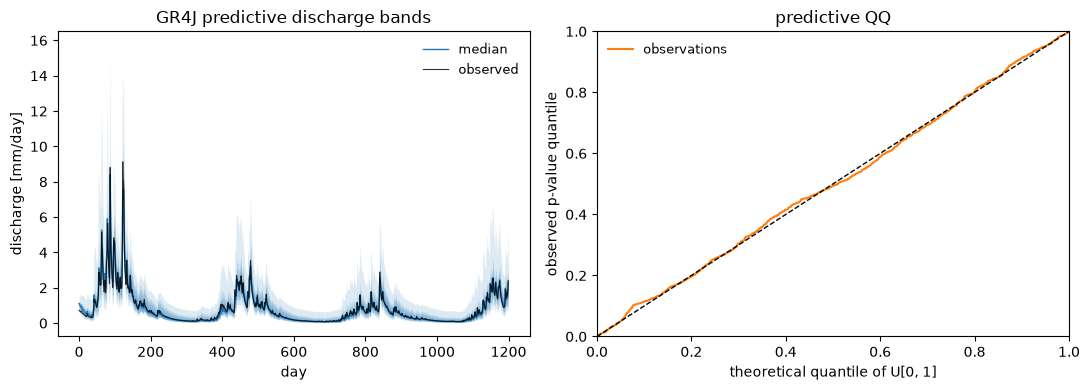

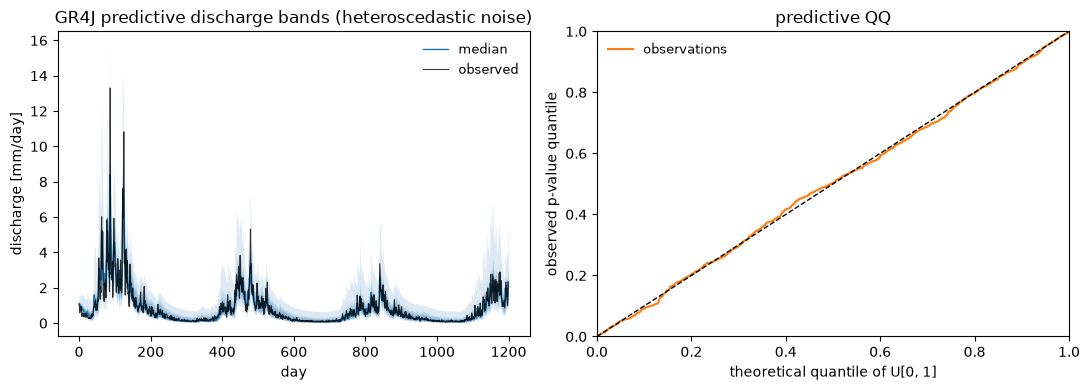

In [47]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
plot_timeseries(bands, gpu.ensemble_.quantiles, observed=yf, ax=a0)
a0.set_title('GR4J predictive discharge bands')
a0.set_xlabel('day')
a0.set_ylabel('discharge [mm/day]')          # plot_timeseries labels default to time/value
plot_qq(gpu.predictive_pvalues(Xf, yf), ax=a1)
a1.set_title('predictive QQ')
fig.tight_layout()

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
plot_timeseries(bands, gpu.ensemble_.quantiles, observed=yf_h, ax=a0)
a0.set_title('GR4J predictive discharge bands (heteroscedastic noise)')
a0.set_xlabel('day')
a0.set_ylabel('discharge [mm/day]')          # plot_timeseries labels default to time/value
plot_qq(gpu_h.predictive_pvalues(Xf_h, yf_h), ax=a1)
a1.set_title('predictive QQ')
fig.tight_layout()

### What the parameters look like

A physical model gives something an MLP cannot: every ensemble member *is* an
interpretable parameter set. The ensemble is the whole population, each member carrying
its own non-exceedance level in `ensemble_.exceedances` — the bands above come from
grouping members by that level — so `ensemble_.params` is a **distribution** of
`X1..X4` spread deliberately across the probability range, not a confidence interval
around one calibration.

Since we know the truth here, we can ask the sharper question too: when the best member
differs from the true parameters, is that the search falling short or the noise? Compare
the training loss at both parameter sets — whichever is lower is the better fit *to the
noisy observations we actually gave it*.

In [52]:
from foresight_gpu.metrics import get_metric
best = int(np.argmin(gpu._fit[:, 1]))       # _fit[:, 1] is log10 of the training loss
names = ['X1 [mm]', 'X2 [mm]', 'X3 [mm]', 'X4 [d]']
lo, hi = np.percentile(gpu.ensemble_.params, [10, 90], axis=0)

print(f'{"":>9}  {"true":>8}  {"best fit":>8}   ensemble p10-p90')
for k, name in enumerate(names):
    print(f'{name:>9}  {true_params[k]:8.2f}  {gpu.ensemble_.params[best, k]:8.2f}   '
          f'{lo[k]:8.2f} - {hi[k]:8.2f}')

# Is the search converged? Evaluate the same 1 - NSE loss at both parameter sets.
nse_loss = get_metric('nse').loss
loss_of = lambda p: float(nse_loss(GR4JModel().forward(Xf, np.atleast_2d(p)), yf)[0])
print()
print(f'training loss (1 - NSE)  best member {loss_of(gpu.ensemble_.params[best]):.4f}'
      f'   true params {loss_of(true_params):.4f}')

print('\nHeteroscedastic noise test:')
best = int(np.argmin(gpu_h._fit[:, 1]))
lo, hi = np.percentile(gpu.ensemble_.params, [10, 90], axis=0)
print(f'{"":>9}  {"true":>8}  {"best fit":>8}   ensemble p10-p90')
for k, name in enumerate(names):
    print(f'{name:>9}  {true_params[k]:8.2f}  {gpu_h.ensemble_.params[best, k]:8.2f}   '
          f'{lo[k]:8.2f} - {hi[k]:8.2f}')
loss_of = lambda p: float(nse_loss(GR4JModel().forward(Xf, np.atleast_2d(p)), yf_h)[0])
print()
print(f'training loss (1 - NSE)  best member {loss_of(gpu.ensemble_.params[best]):.4f}'
      f'   true params {loss_of(true_params):.4f}')

               true  best fit   ensemble p10-p90
  X1 [mm]    350.00    344.66     266.29 -   352.23
  X2 [mm]      0.50      1.16      -1.64 -     1.48
  X3 [mm]     90.00    138.47     123.83 -   165.60
   X4 [d]      1.70      1.56       1.50 -     1.70

training loss (1 - NSE)  best member 0.0222   true params 0.0000

Heteroscedastic noise test:
               true  best fit   ensemble p10-p90
  X1 [mm]    350.00    261.49     266.29 -   352.23
  X2 [mm]      0.50      0.47      -1.64 -     1.48
  X3 [mm]     90.00    143.55     123.83 -   165.60
   X4 [d]      1.70      1.32       1.50 -     1.70

training loss (1 - NSE)  best member 0.1178   true params 0.1013


The bands follow the seasonal hydrograph and widen at high flow, matching the
multiplicative error — GPU adapts the distribution shape without being told to, and the
QQ plot stays near the diagonal (reliability ≈ 0.99).

Two caveats worth carrying to real data:

- The wide `ensemble_.params` spread is **not** an error bar on a calibration. The
  population is spread across non-exceedance levels on purpose — that is what makes the
  bands reliable — and the min-loss corner is only one member of it.
- The sign of that loss comparison can flip. Lengthen the series and shrink the error
  (`n = 4000`, `0.05` instead of `0.25`) and the true parameters start fitting *better*
  than the best member, i.e. the `population=400, n_iter=80` quickstart budget becomes the
  binding constraint rather than the noise. Re-run the check above before reading physical
  meaning into `X1..X4`, and raise the budget when it says the search is short.

The transferable point: swapping `MLPModel` for `GR4JModel` changed nothing about the GPU
interface — only the number and meaning of the forcing columns.

Next: the `BaseForwardModel` contract, so you can plug in your own model
(`02_custom_model`); a real seasonal forecast on Zambezi data (`01_seasonal_forecast`) —
and `foresight_gpu.utils.OudinPET` if you have temperature rather than PET; then
diagnostics and model selection (`03_diagnostics`).